# Analysis with Jing/Robert (JR) extraction of $R_{rs}$

In [13]:
# imports
from importlib import reload
import os, sys
import numpy as np

from matplotlib import pyplot as plt

import xarray
import pandas

from ocpy.pace import io as pace_io
from ocpy.utils import plotting

from bing.parameters import standard
from bing.models import utils as model_utils
from bing.priors import priors as bing_priors
from bing.fitting import inference as bing_inf
from bing import evaluate
from bing.fitting import chisq_fit
from bing import plotting as bing_plotting

# Locals
sys.path.append(os.path.abspath("../py"))
import jr_utils
import biomass_io

# Load 

## JR file

In [4]:
jr_file = '../Frouin/jr_test_matchup_L1B.csv'
jr_df = pandas.read_csv(jr_file)
jr_df.head()

,AOP_file,L1B_file,PACE_lat,PACE_lon,time,dist,Comments,"Rrs_mean_339.16nm, 1/sr","Rrs_mean_341.32nm, 1/sr","Rrs_mean_343.63nm, 1/sr",...,"Rrs_obpg_std_705.59nm, 1/sr","Rrs_obpg_std_706.83nm, 1/sr","Rrs_obpg_std_708.09nm, 1/sr","Rrs_obpg_std_709.33nm, 1/sr","Rrs_obpg_std_710.58nm, 1/sr","Rrs_obpg_std_711.82nm, 1/sr","Rrs_obpg_std_713.06nm, 1/sr","Rrs_obpg_std_714.32nm, 1/sr","Rrs_obpg_std_716.82nm, 1/sr","Rrs_obpg_std_719.30nm, 1/sr"
0,PACE_OCI.20250125T223228.L2.OC_AOP.V3_1.nc,PACE_OCI.20250125T223228.L1B.V3.nc,3.950078,-136.680191,2025-01-25 13:05:59.999995392+00:00,3.877104,*cloudy (3 pixels of 9 are clear),0.006396,0.006397,0.006398,...,0.000039,0.000040,0.000034,0.000033,0.000025,0.000021,0.000012,0.000016,0.000049,0.000058
1,PACE_OCI.20250204T214610.L2.OC_AOP.V3_1.nc,PACE_OCI.20250204T214610.L1B.V3.nc,3.734074,-136.198715,2025-02-04 18:59:59.999996416+00:00,8.277993,*cloudy (2 pixels out of 9 are clear),0.005968,0.005968,0.005969,...,0.000108,0.000101,0.000099,0.000093,0.000076,0.000066,0.000031,0.000008,0.000091,0.000065
2,PACE_OCI.20250215T214320.L2.OC_AOP.V3_1.nc,PACE_OCI.20250215T214320.L1B.V3.nc,3.942290,-135.770966,2025-02-15 01:49:59.999998976+00:00,1.999847,*cloudy (4 pixels out of 9 are clear),0.006268,0.006269,0.006270,...,0.000010,0.000009,0.000009,0.000013,0.000017,0.000013,0.000012,0.000028,0.000073,0.000041
3,PACE_OCI.20250225T224351.L2.OC_AOP.V3_1.nc,PACE_OCI.20250225T224351.L1B.V3.nc,4.226517,-135.253601,2025-02-25 07:24:00.000001536+00:00,16.813300,"*image edge, cloudy (1 pixel out of 9 is clear)",0.007117,0.007118,0.007119,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,PACE_OCI.20250327T222202.L2.OC_AOP.V3_1.nc,PACE_OCI.20250327T222202.L1B.V3.nc,3.832357,-134.277969,2025-03-28 02:37:00.000001536+00:00,1.083999,*cloudy (8 pixels out of 9 are clear),0.006176,0.006177,0.006178,...,0.000057,0.000045,0.000042,0.000040,0.000036,0.000045,0.000052,0.000077,0.000108,0.000113


In [5]:
jr_df.keys()

Index(['AOP_file', 'L1B_file', 'PACE_lat', 'PACE_lon', 'time', 'dist',
       'Comments', 'Rrs_mean_339.16nm, 1/sr', 'Rrs_mean_341.32nm, 1/sr',
       'Rrs_mean_343.63nm, 1/sr',
       ...
       'Rrs_obpg_std_705.59nm, 1/sr', 'Rrs_obpg_std_706.83nm, 1/sr',
       'Rrs_obpg_std_708.09nm, 1/sr', 'Rrs_obpg_std_709.33nm, 1/sr',
       'Rrs_obpg_std_710.58nm, 1/sr', 'Rrs_obpg_std_711.82nm, 1/sr',
       'Rrs_obpg_std_713.06nm, 1/sr', 'Rrs_obpg_std_714.32nm, 1/sr',
       'Rrs_obpg_std_716.82nm, 1/sr', 'Rrs_obpg_std_719.30nm, 1/sr'],
      dtype='object', length=1155)

In [6]:
len(jr_df)

15

In [27]:
jr_df.Comments

0                   *cloudy (3 pixels of 9 are clear)
1               *cloudy (2 pixels out of 9 are clear)
2               *cloudy (4 pixels out of 9 are clear)
3     *image edge, cloudy (1 pixel out of 9 is clear)
4               *cloudy (8 pixels out of 9 are clear)
5           *image edge (4 pixels out of 9 are clear)
6                     *clear (all 9 pixels are clear)
7                     *clear (all 9 pixels are clear)
8               *cloudy (2 pixels out of 9 are clear)
9                                                 NaN
10                                                NaN
11                                                NaN
12                                                NaN
13                                                NaN
14                                                NaN
Name: Comments, dtype: object

In [28]:
jr_df.iloc[6]

AOP_file                       PACE_OCI.20250219T155847.L2.OC_AOP.V3_1.nc
L1B_file                               PACE_OCI.20250219T155847.L1B.V3.nc
PACE_lat                                                        27.481264
PACE_lon                                                        -46.21777
time                                  2025-02-18 20:26:59.999997440+00:00
                                                  ...                    
Rrs_obpg_std_711.82nm, 1/sr                                      0.000024
Rrs_obpg_std_713.06nm, 1/sr                                      0.000023
Rrs_obpg_std_714.32nm, 1/sr                                      0.000022
Rrs_obpg_std_716.82nm, 1/sr                                      0.000029
Rrs_obpg_std_719.30nm, 1/sr                                      0.000038
Name: 6, Length: 1155, dtype: object

## Matched

In [7]:
match_file = '../matched_argo_bgc_profiles_bbp_v3.csv'
m_df = pandas.read_csv(match_file)
m_df.head()

,cruise,filename,profile,lat,lon,time,solar_angle,pace_ids,closest_id,closest_file,closest_dist_km,closest_time,BING_Bnw,BING_Bnw_std,BING_Bnw_lsig,BING_Bnw_hsig,BING_beta,BING_aph,argo_bbp700
0,1902367,1902367QC.nc,11,3.709,88.955,2025-05-31 09:39:59.999997952+00:00,34.158235,PACE_OCI_L2_AOP_PACE_OCI.20250601T070425.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20250601T070425.L2.OC...,PACE_OCI.20250601T070425.L2.OC_AOP.V3_1.nc,0.734763,2025-06-01 07:06:54.500000+00:00,0.000829,0.000205,0.000057,0.000056,1.696046,0.004255,0.000642
1,1902368,1902368QC.nc,13,56.348,-147.356,2024-07-09 04:35:00.000002048+00:00,13.134825,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240708T202028.L2.OC...,PACE_OCI.20240708T202028.L2.OC_AOP.V3_1.nc,671.392674,2024-07-08 20:22:57.500000+00:00,0.002596,0.000500,0.000134,0.000141,1.789959,0.005123,0.001293
2,1902369,1902369QC.nc,4,45.006,-133.357,2024-05-09 22:07:00.000001536+00:00,58.276589,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_1.nc,0.620598,2024-05-10 20:36:38.500000+00:00,0.000652,0.000084,0.000064,0.000071,1.118243,0.002820,0.000683
3,1902369,1902369QC.nc,5,45.020,-133.356,2024-05-10 09:02:59.999999488+00:00,-27.116450,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_1.nc,0.579841,2024-05-10 20:36:38.500000+00:00,0.000648,0.000161,0.000068,0.000072,1.098381,0.002145,0.000644
4,1902369,1902369QC.nc,6,45.020,-133.354,2024-05-10 19:52:59.999998464+00:00,60.421381,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI_L2_AOP_PACE_OCI.20240510T203409.L2.OC...,PACE_OCI.20240510T203409.L2.OC_AOP.V3_1.nc,0.709744,2024-05-10 20:36:38.500000+00:00,0.000648,0.000164,0.000068,0.000072,1.098381,0.002145,0.000688


# Plot one

## Grab JR spectra

In [30]:
# JR_ID = 0
cruise, profile = 7902136, 7
# JR_ID = 6
cruise, profile = 7902226, 4
#
jr_dict = jr_utils.extract_rrs(cruise, profile)
#jr_dict.keys()

## Grab PACE

In [31]:
m_profile = biomass_io.get_matched_profile(m_df, cruise, profile)
m_profile

cruise                                                       7902226
filename                                                7902226QC.nc
profile                                                            4
lat                                                           27.479
lon                                                          -46.221
time                             2025-02-18 20:26:59.999997440+00:00
solar_angle                                                 6.099996
pace_ids           PACE_OCI_L2_AOP_PACE_OCI.20250219T155847.L2.OC...
closest_id         PACE_OCI_L2_AOP_PACE_OCI.20250219T155847.L2.OC...
closest_file              PACE_OCI.20250219T155847.L2.OC_AOP.V3_1.nc
closest_dist_km                                             0.406164
closest_time                               2025-02-19 16:01:17+00:00
BING_Bnw                                                    0.000975
BING_Bnw_std                                                0.000194
BING_Bnw_lsig                     

In [32]:
fit_file = biomass_io.get_fit_file_path(m_profile)
bing_fit = biomass_io.load_fit_data(fit_file)
bing_fit.keys()

KeysView(NpzFile '/home/xavier/Projects/Oceanography/data/Color/Biomass/Fits/Argo_7902226_004_fits.npz' with keys: chains, LM, wave, Rrs, Rrs_sig...)

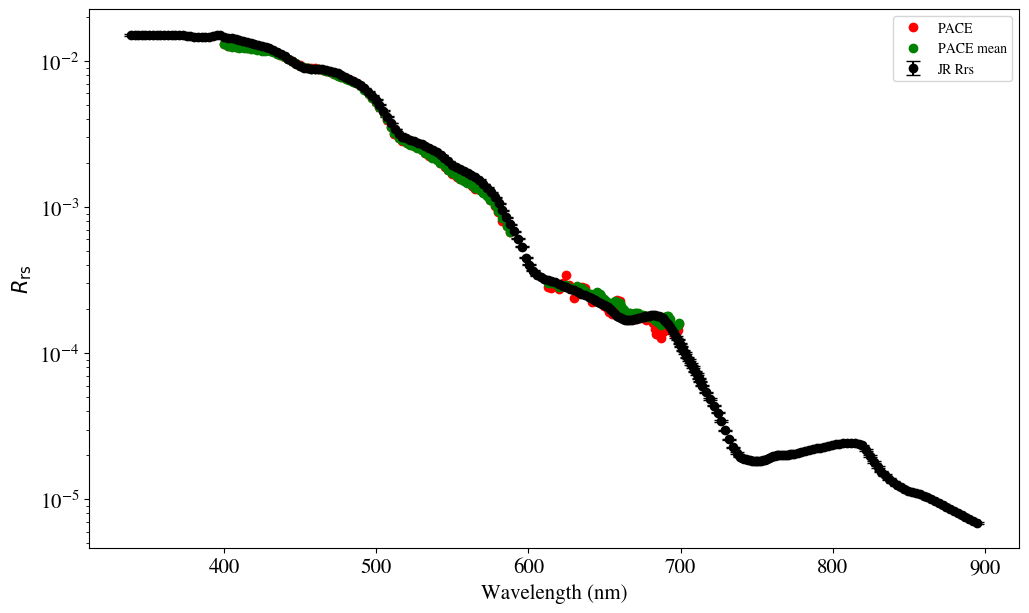

In [33]:
fig = plt.figure(figsize=(12,7))
ax = plt.gca()
# JR
ax.errorbar(jr_dict['wavelengths'], jr_dict['Rrs_mean'], yerr=jr_dict['Rrs_std'],
                color='k',  fmt='o', capsize=5, label='JR Rrs') 
# PACE
ax.plot(bing_fit['wave'][0], bing_fit['Rrs'][0], 'ro',  label='PACE')
# PACE mean
ax.plot(bing_fit['wave'][0], np.mean(bing_fit['Rrs'], axis=0), 'go',  label='PACE mean')
#
ax.set_yscale('log')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$R_{\rm rs}$')

ax.legend()
#
plotting.set_fontsize(ax, 15.)
#
plt.show()

# Fit one

## Parse out the data

In [11]:
ix, iy = 1000, 200
gd_wave = (xds.wavelength.data >= 400.) &  (xds.wavelength.data <= 700.) 
iwave = xds.wavelength.data[gd_wave]
ispec = xds.Rrs.data[ix,iy,gd_wave]
isig = xds.Rrs_unc.data[ix,iy,gd_wave]

In [12]:
iwave

array([400, 403, 405, 408, 410, 413, 415, 418, 420, 422, 425, 427, 430,
       432, 435, 437, 440, 442, 445, 447, 450, 452, 455, 457, 460, 462,
       465, 467, 470, 472, 475, 477, 480, 482, 485, 487, 490, 492, 495,
       497, 500, 502, 505, 507, 510, 512, 515, 517, 520, 522, 525, 527,
       530, 532, 535, 537, 540, 542, 545, 547, 550, 553, 555, 558, 560,
       563, 565, 568, 570, 573, 575, 578, 580, 583, 586, 588, 613, 615,
       618, 620, 623, 625, 627, 630, 632, 635, 637, 640, 641, 642, 643,
       645, 646, 647, 648, 650, 651, 652, 653, 655, 656, 657, 658, 660,
       661, 662, 663, 665, 666, 667, 668, 670, 671, 672, 673, 675, 676,
       677, 678, 679, 681, 682, 683, 684, 686, 687, 688, 689, 691, 692,
       693, 694, 696, 697, 698, 699], dtype=int32)

## Parameters

In [13]:
p = standard.expb_pow()
p

BING20_tuple(model_names=['ExpBricaud', 'Pow'], scl_noise='PACE', wv_min=400.0, wv_max=700.0, satellite='PACE', add_noise=False, apriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.01, 'pmax': 0.02}, {'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}], bpriors=[{'flavor': 'log_uniform', 'pmin': -6, 'pmax': 5}, {'flavor': 'uniform', 'pmin': 0.0, 'pmax': 2.0}], set_Sdg=False, sSdg=0.002, beta=None, nMC=None, nsteps=40000, nburn=1000)

## Models

In [14]:
# Models
models = model_utils.init(p.model_names, iwave)

In [15]:
models

[<aNWModel: ExpBricaud, nparam=3>, <bbNWModel: Pow, nparam=2>]

## Priors

In [16]:
bing_priors.set_standard_priors(models, p)

## Initialize the MCMC

In [17]:
pdict = bing_inf.init_mcmc(models, nsteps=p.nsteps, nburn=p.nburn)

In [18]:
pdict['Chl'] = np.array([0.1 / 0.05582])
pdict['Y'] = None

## Items

In [49]:
#p0 = [-1, 0.015, -1, -1, 1.5]
p0 = ans.tolist()
items = [(ispec, isig**2, p0, 0)]

## Fit me

## Check me

In [50]:
chains, idx = bing_inf.fit_one(
        items[0], models=models, pdict=pdict, chains_only=True)

idx=0
Running burn-in


  0%|                                                 | 0/1000 [00:00<?, ?it/s]/home/xavier/miniconda3/envs/ocean/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████| 1000/1000 [00:01<00:00, 687.03it/s]


Running full model


100%|███████████████████████████████████| 40000/40000 [00:56<00:00, 707.74it/s]


In [56]:
chains.shape

(40000, 16, 5)

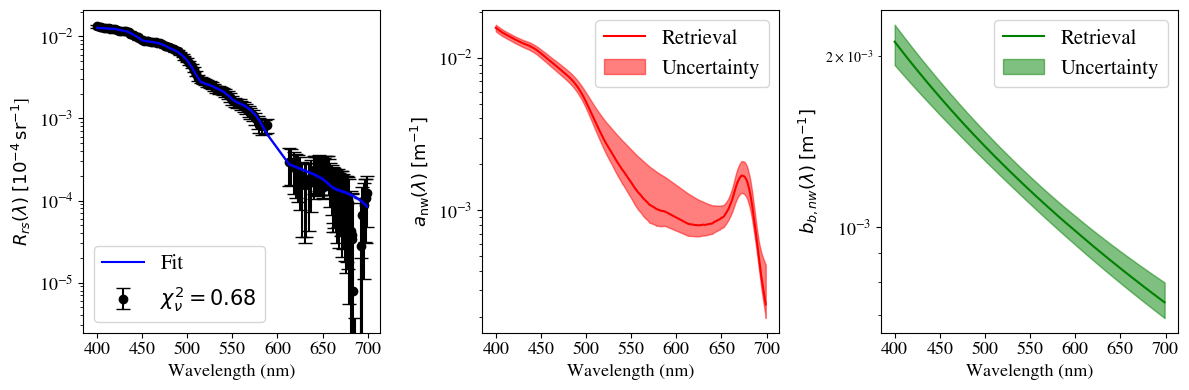

In [51]:
reload(bing_plotting)
bing_plotting.show_fits(models, chains,  None, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                        log_abb=True,
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

# Try chi^2

## Set Bounds

In [32]:
#p.apriors
low_bounds, high_bounds = [], []
low_bounds += [item['pmin'] for item in p.apriors]
low_bounds += [item['pmin'] for item in p.bpriors]
high_bounds += [item['pmax'] for item in p.apriors]
high_bounds += [item['pmax'] for item in p.bpriors]
#
bounds = (np.array(low_bounds), np.array(high_bounds))
#
bounds

(array([-6.  ,  0.01, -6.  , -6.  ,  0.  ]),
 array([5.  , 0.02, 5.  , 5.  , 2.  ]))

In [42]:
p0

[-1, 0.015, -1, -1, 1.5]

## Fit

In [43]:
reload(chisq_fit)
ans, cov, idx = chisq_fit.fit(items[0], models, bounds=bounds)
ans

array([-1.89600591,  0.01829992, -2.23742088, -3.01622879,  2.        ])

In [48]:
models[0].pnames, models[1].pnames

(['Adg', 'Sdg', 'Aph'], ['Bnw', 'beta'])

### Show

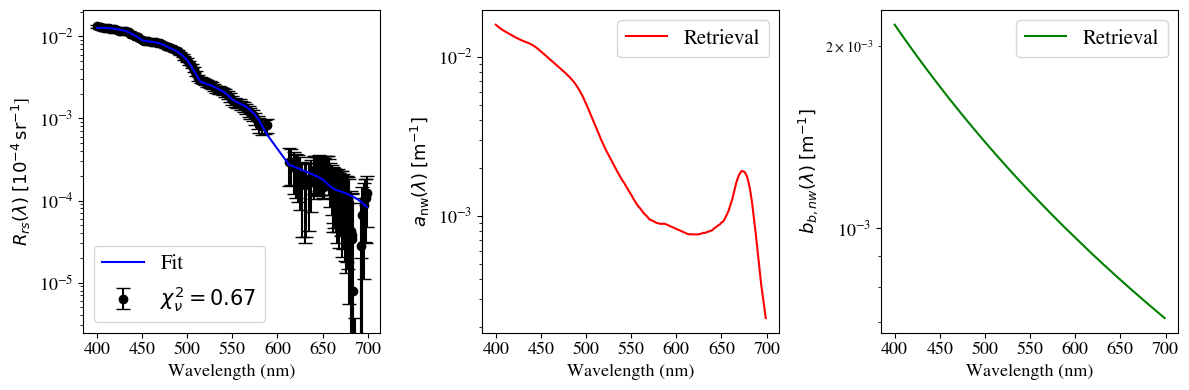

In [47]:
reload(bing_plotting)
Chl = 10**ans[-1] / 0.05582
bing_plotting.show_fits(models, ans,  Chl, None,
                figsize=(12,4),
                fontsize=13.,
                Rrs_true=dict(wave=models[0].wave, spec=ispec, var=isig**2),
                  log_abb=True,
                        
                   #Rrs_true=dict(wave=df_lee.wave, spec=gordon_Rrs_1),
                #anw_true=anw_dict, bbnw_true=bbnw_dict,
                )
plt.show()

In [49]:
models[0].uses_Chl

True

----

In [53]:
burn, thin = 7000, 1

In [54]:
cchains = chains[burn::thin, :, :].reshape(-1, chains.shape[-1])

In [56]:
np.median(cchains, axis=0)

array([-1.8882558 ,  0.01656702, -2.2996569 , -3.006781  ,  1.9095559 ],
      dtype=float32)

In [58]:
np.percentile(cchains, 5, axis=0)

array([-1.9294134 ,  0.01225657, -2.51087   , -3.031094  ,  1.6396716 ],
      dtype=float32)

In [45]:
cchains.shape

(528000, 5)

In [62]:
reload(evaluate)
evaluate.calc_stats(chains)

{'names': ['p0', 'p1', 'p2', 'p3', 'p4'],
 'med': array([-1.8882558 ,  0.01656702, -2.2996569 , -3.006781  ,  1.9095559 ],
       dtype=float32),
 'p05': array([-1.9294134 ,  0.01225657, -2.51087   , -3.031094  ,  1.6396716 ],
       dtype=float32),
 'p95': array([-1.8406658 ,  0.01963136, -2.197699  , -2.980707  ,  1.9930469 ],
       dtype=float32)}

In [63]:
ans


array([-1.89600591,  0.01829992, -2.23742088, -3.01622879,  2.        ])